# Phase Metrics — Circular Statistics Analysis

Analyses `phase_mean` (true circular direction) and `phase_locking_vector_length` / `phase_variance` (concentration/dispersion metrics) using **pycircstat2**.

## Which column gets which treatment

| Column | Nature | Approach |
|---|---|---|
| `phase_mean` | True angle (radians) | Full circular stats: Rayleigh, Watson-Williams / Watson U², Wallraff, circ_anova |
| `phase_locking_vector_length` | Scalar concentration (0–1) | Circular descriptives per group; Wallraff test for dispersion differences; permutation test |
| `phase_variance` | Scalar dispersion (0–1) | Same as above |
| `phase_locked` | Binary (0/1) | Keep as binomial GLMM (already done in main analysis) |

## Test selection logic for `phase_mean`

1. **Rayleigh test** per group — does the group show directional clustering at all?  
   If concentration r > 0.7: Watson-Williams (parametric F-test on mean direction).  
   If r ≤ 0.7 or distribution non-unimodal: Watson U² or Wheeler-Watson (non-parametric).  
2. **Wallraff test** — compares *dispersion* (concentration) between groups independently of direction.
3. **circ_anova** — Genotype × Cell_type factorial design on directions.

## Note on nested structure
pycircstat2 operates on cell-level angular data directly. There is no mixed-model equivalent for circular data in Python yet.
To account for the nested structure (cells within mice), we run **animal-level summaries** as a supplementary check:
compute the mean vector per mouse, then test on those animal-level angles.

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages
from IPython.display import display, HTML

# ── pycircstat2 imports ──────────────────────────────────────────────────────
from pycircstat2 import Circular
from pycircstat2.hypothesis import (
    rayleigh_test,
    watson_williams_test,
    wheeler_watson_test,
    wallraff_test,
    circ_anova,
)
from pycircstat2.descriptive import circ_mean, circ_r

print("✅ All packages loaded")

✅ All packages loaded


In [2]:
# ── Custom Watson U² test (handles unequal sample sizes) ────────────────────
from types import SimpleNamespace

def watson_u2_test(circulars, n_perm=9999, seed=42):
    """
    Watson U² two-sample test with permutation p-value.
    Replaces pycircstat2's version, which requires equal n.
    Accepts a list of two pycircstat2 Circular objects.
    Returns object with .U2 and .pval attributes.
    """
    rng = np.random.default_rng(seed)
    a1 = np.sort(circulars[0].alpha % (2 * np.pi))
    a2 = np.sort(circulars[1].alpha % (2 * np.pi))
    n1, n2 = len(a1), len(a2)

    def u2_stat(x, y):
        n, m = len(x), len(y)
        combined = np.sort(np.concatenate([x, y]))
        F1 = np.searchsorted(x, combined, side='right') / n
        F2 = np.searchsorted(y, combined, side='right') / m
        d = F1 - F2
        return (n * m / (n + m) ** 2) * (np.sum(d**2) - np.sum(d)**2 / (n + m))

    observed = u2_stat(a1, a2)
    combined_all = np.concatenate([a1, a2])
    count = 0
    for _ in range(n_perm):
        perm = rng.permutation(combined_all)
        stat = u2_stat(np.sort(perm[:n1]), np.sort(perm[n1:]))
        if stat >= observed:
            count += 1

    return SimpleNamespace(U2=observed, pval=(count + 1) / (n_perm + 1))

print("✅ Custom watson_u2_test defined (handles unequal n, permutation p-value)")

✅ Custom watson_u2_test defined (handles unequal n, permutation p-value)


## 2. Load and Prepare Data

In [3]:
# ── Paths ────────────────────────────────────────────────────────────────────
CSV_PATH = Path('/Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/OF_concat/concatenated_trials.csv')
OUTPUT_DIR = CSV_PATH.parent / 'phase_circular_analysis'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Load ─────────────────────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)

# phase_mean is stored in radians — verify range
print(f"phase_mean range: {df['phase_mean'].min():.3f} to {df['phase_mean'].max():.3f} rad")
print(f"  (should be roughly -π to π or 0 to 2π)")
print(f"Environments: {df['environment'].unique()}")
print(f"Cell types:   {df['cell_type'].unique()}")
print(f"Genotypes:    {df['Genotype'].unique()}")
print(f"Total rows:   {len(df)}")

# ── Convert phase_mean to [0, 2π) if stored as [-π, π] ──────────────────────
# pycircstat2 works with either, but be consistent
# Uncomment if your phase_mean is in degrees:
# df['phase_mean_rad'] = np.deg2rad(df['phase_mean'])
# Otherwise (already in radians):
df['phase_mean_rad'] = df['phase_mean'] % (2 * np.pi)   # wrap to [0, 2π)

# ── Constants ────────────────────────────────────────────────────────────────
ENVIRONMENTS = ['open_field', 'linear_track']
CELL_TYPES   = ['Pyramidal', 'Interneuron']
GENOTYPES    = ['WT', 'NLGF']
GENO_COLORS  = {'WT': '#5B8DB8', 'NLGF': '#E07B54'}
CT_COLORS    = {'Pyramidal': '#2ecc71', 'Interneuron': '#9b59b6'}

def sig_label(p):
    if pd.isna(p): return 'NA'
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

print("\n✅ Data loaded and prepared")

phase_mean range: 0.000 to 6.283 rad
  (should be roughly -π to π or 0 to 2π)
Environments: ['open_field' 'linear_track']
Cell types:   ['Pyramidal' 'Interneuron']
Genotypes:    ['NLGF' 'WT']
Total rows:   1838

✅ Data loaded and prepared


## 3. Helper Functions

In [4]:
def get_angles(df, env, ct, geno, col='phase_mean_rad'):
    """Return clean angle array for one env × cell type × genotype slice."""
    mask = (
        (df['environment'] == env) &
        (df['cell_type']   == ct)  &
        (df['Genotype']    == geno)
    )
    return df.loc[mask, col].dropna().values


def make_circular(angles_rad, min_n=5):
    """Wrap angles in a pycircstat2 Circular object. Returns None if too few data."""
    if len(angles_rad) < min_n:
        return None
    return Circular(angles_rad, unit='radian')


def animal_mean_angle(df, env, ct, geno, col='phase_mean_rad'):
    """
    Compute the mean resultant vector angle per mouse, then return
    the array of those animal-level mean angles.
    This respects the nested structure (cells within mice).
    """
    mask = (
        (df['environment'] == env) &
        (df['cell_type']   == ct)  &
        (df['Genotype']    == geno)
    )
    sub = df.loc[mask, ['mouse_name', col]].dropna()
    if sub.empty:
        return np.array([])

    animal_means = []
    for mouse, grp in sub.groupby('mouse_name'):
        angles = grp[col].values
        if len(angles) >= 2:
            mu = circ_mean(angles) % (2 * np.pi)   # keep in [0, 2π)
            animal_means.append(mu)
    return np.array(animal_means)


def rayleigh_summary(circ_obj):
    """Return dict of key Rayleigh test stats from a Circular object."""
    res = circ_obj.mean_test_result
    return {
        'r': circ_obj.r,
        'mean_deg': np.degrees(circ_obj.mean) % 360,
        'kappa': circ_obj.kappa,
        'rayleigh_p': res.pval,
        'n': circ_obj.n,
    }


print("✅ Helper functions defined")

✅ Helper functions defined


## 4. Rayleigh Tests — Is There Any Directional Preference per Group?

Run per environment × cell type × genotype. This tells us whether cells preferentially fire at a particular theta phase at all, before asking whether genotypes differ.

This cell runs the **Rayleigh test** for each combination of environment × cell type × genotype and produces two outputs:

---

### 1. The `df_rayleigh` table

One row per group (e.g. `open_field | Pyramidal | WT`). Key columns:

| Column | Meaning |
|---|---|
| `n` | Number of cells in that group |
| `r` | **Mean resultant length** (0–1). How tightly clustered the phase angles are. `r=0` = uniform/random, `r=1` = all cells fire at exactly the same phase |
| `mean_direction_deg` | The average theta phase the group fires at (in degrees) |
| `kappa` | Von Mises concentration parameter — higher = sharper/tighter locking |
| `rayleigh_p` | p-value: is the distribution *significantly non-uniform*? i.e., do cells fire preferentially at any phase at all? |
| `sig` | `*`/`**`/`***`/`ns` from that p-value |
| `interpretation` | "Significant phase preference" if `p < 0.05` |

---

### 2. The `low_r` warning (your selected line)

```
⚠️  Groups with r < 0.7 (use non-parametric tests for these):
 environment  cell_type  genotype     r  sig
  open_field  Pyramidal        WT  0.42   **
  ...
```

This lists every group whose concentration `r < 0.7`. This matters because:
- **Watson-Williams** (parametric F-test on direction) assumes high concentration (approximately von Mises with large κ), and is only reliable when **both** groups have `r > 0.7`
- When `r ≤ 0.7`, the data may be too spread out or non-unimodal for the parametric test → Section 5 will automatically flag these and recommend **Watson U²** or **Wheeler-Watson** instead

In practice with theta phase data, `r` is often low (cells don't all fire at *exactly* the same phase), so you'll likely see most or all groups flagged here — meaning the non-parametric tests in Section 5 will be the primary results to trust.

In [5]:
rayleigh_rows = []

for env in ENVIRONMENTS:
    for ct in CELL_TYPES:
        for geno in GENOTYPES:
            angles = get_angles(df, env, ct, geno)
            circ = make_circular(angles)
            if circ is None:
                continue

            stats = rayleigh_summary(circ)
            rayleigh_rows.append({
                'environment': env,
                'cell_type':   ct,
                'genotype':    geno,
                'n':           stats['n'],
                'r':           round(stats['r'], 4),
                'mean_direction_deg': round(stats['mean_deg'], 1),
                'kappa':       round(stats['kappa'], 3),
                'rayleigh_p':  round(stats['rayleigh_p'], 5),
                'sig':         sig_label(stats['rayleigh_p']),
                'interpretation': (
                    'Significant phase preference'
                    if stats['rayleigh_p'] < 0.05
                    else 'No significant phase preference'
                ),
            })

df_rayleigh = pd.DataFrame(rayleigh_rows)

display(HTML("<h3>Rayleigh Test Results — Phase Mean</h3>"))
display(df_rayleigh)

df_rayleigh.to_csv(OUTPUT_DIR / '1_rayleigh_test_results.csv', index=False)
print("\n✅ Saved: 1_rayleigh_test_results.csv")

# Flag low concentration groups — affects which two-sample test to use
low_r = df_rayleigh[df_rayleigh['r'] < 0.7]
if not low_r.empty:
    print("\n⚠️  Groups with r < 0.7 (use non-parametric tests for these):")
    print(low_r[['environment', 'cell_type', 'genotype', 'r', 'sig']].to_string(index=False))

,environment,cell_type,genotype,n,r,mean_direction_deg,kappa,rayleigh_p,sig,interpretation
0,open_field,Pyramidal,WT,409,0.3405,186.2,0.724,0.00000,***,Significant phase preference
1,open_field,Pyramidal,NLGF,310,0.2987,169.7,0.626,0.00000,***,Significant phase preference
2,open_field,Interneuron,WT,148,0.3651,211.4,0.784,0.00000,***,Significant phase preference
3,open_field,Interneuron,NLGF,211,0.3680,194.6,0.792,0.00000,***,Significant phase preference
4,linear_track,Pyramidal,WT,292,0.2058,152.9,0.421,0.00000,***,Significant phase preference
5,linear_track,Pyramidal,NLGF,221,0.2071,198.7,0.423,0.00007,***,Significant phase preference
6,linear_track,Interneuron,WT,101,0.3353,213.2,0.712,0.00001,***,Significant phase preference
7,linear_track,Interneuron,NLGF,146,0.2816,233.0,0.587,0.00001,***,Significant phase preference



✅ Saved: 1_rayleigh_test_results.csv

⚠️  Groups with r < 0.7 (use non-parametric tests for these):
 environment   cell_type genotype      r sig
  open_field   Pyramidal       WT 0.3405 ***
  open_field   Pyramidal     NLGF 0.2987 ***
  open_field Interneuron       WT 0.3651 ***
  open_field Interneuron     NLGF 0.3680 ***
linear_track   Pyramidal       WT 0.2058 ***
linear_track   Pyramidal     NLGF 0.2071 ***
linear_track Interneuron       WT 0.3353 ***
linear_track Interneuron     NLGF 0.2816 ***


## 5. Two-Sample Tests on `phase_mean` Direction — WT vs NLGF

For each environment × cell type:
- **Watson-Williams F-test** (parametric, assumes von Mises, appropriate when both groups have r > 0.7)
- **Watson U² test** (non-parametric, use when r ≤ 0.7 or distribution is non-unimodal)
- **Wheeler-Watson test** (non-parametric multi-sample alternative)

All three are reported; the primary test to trust is selected based on concentration.

In [6]:
direction_test_rows = []

for env in ENVIRONMENTS:
    for ct in CELL_TYPES:
        angles_wt   = get_angles(df, env, ct, 'WT')
        angles_nlgf = get_angles(df, env, ct, 'NLGF')

        circ_wt   = make_circular(angles_wt)
        circ_nlgf = make_circular(angles_nlgf)

        if circ_wt is None or circ_nlgf is None:
            print(f"⚠️  Skipped {env} | {ct}: insufficient data")
            continue

        # Concentrations
        r_wt   = circ_wt.r
        r_nlgf = circ_nlgf.r
        both_high_r = (r_wt > 0.7) and (r_nlgf > 0.7)

        row = {
            'environment': env,
            'cell_type':   ct,
            'n_WT':        circ_wt.n,
            'n_NLGF':      circ_nlgf.n,
            'r_WT':        round(r_wt, 4),
            'r_NLGF':      round(r_nlgf, 4),
            'mean_deg_WT':   round(np.degrees(circ_wt.mean) % 360, 1),
            'mean_deg_NLGF': round(np.degrees(circ_nlgf.mean) % 360, 1),
            'recommended_test': 'watson_williams' if both_high_r else 'watson_u2',
        }

        # ── Watson-Williams (parametric) ─────────────────────────────────────
        try:
            ww = watson_williams_test([circ_wt, circ_nlgf])
            row['WW_F']   = round(ww.F, 4)
            row['WW_p']   = round(ww.pval, 5)
            row['WW_sig'] = sig_label(ww.pval)
        except Exception as e:
            row['WW_F'], row['WW_p'], row['WW_sig'] = np.nan, np.nan, f'ERROR: {e}'

        # ── Watson U² (non-parametric) ───────────────────────────────────────
        try:
            wu2 = watson_u2_test([circ_wt, circ_nlgf])
            row['WU2_U2']  = round(wu2.U2, 5)
            row['WU2_p']   = round(wu2.pval, 5)
            row['WU2_sig'] = sig_label(wu2.pval)
        except Exception as e:
            print(f"WU2 ERROR for {env}|{ct}: {e}") 
            row['WU2_U2'], row['WU2_p'], row['WU2_sig'] = np.nan, np.nan, f'ERROR: {e}'

        # ── Wheeler-Watson (non-parametric) ──────────────────────────────────
        try:
            ww2 = wheeler_watson_test([circ_wt, circ_nlgf])
            row['WheelWat_W']   = round(ww2.W, 4)
            row['WheelWat_p']   = round(ww2.pval, 5)
            row['WheelWat_sig'] = sig_label(ww2.pval)
        except Exception as e:
            row['WheelWat_W'], row['WheelWat_p'], row['WheelWat_sig'] = np.nan, np.nan, f'ERROR: {e}'

        direction_test_rows.append(row)
        print(f"{env} | {ct}: WW_p={row.get('WW_p', 'NA')} {row.get('WW_sig','')}, "
              f"WU2_p={row.get('WU2_p', 'NA')} {row.get('WU2_sig','')}, "
              f"  [recommended: {row['recommended_test']}]")

df_direction = pd.DataFrame(direction_test_rows)

display(HTML("<h3>WT vs NLGF — Direction Tests on phase_mean</h3>"))
display(df_direction)

df_direction.to_csv(OUTPUT_DIR / '2_direction_tests_WT_vs_NLGF.csv', index=False)
print("\n✅ Saved: 2_direction_tests_WT_vs_NLGF.csv")

open_field | Pyramidal: WW_p=0.02187 *, WU2_p=0.0105 *,   [recommended: watson_u2]
open_field | Interneuron: WW_p=0.07529 ns, WU2_p=0.0015 **,   [recommended: watson_u2]
linear_track | Pyramidal: WW_p=1e-05 ***, WU2_p=0.0392 *,   [recommended: watson_u2]
linear_track | Interneuron: WW_p=0.11344 ns, WU2_p=0.2699 ns,   [recommended: watson_u2]


,environment,cell_type,n_WT,n_NLGF,r_WT,r_NLGF,mean_deg_WT,mean_deg_NLGF,recommended_test,WW_F,WW_p,WW_sig,WU2_U2,WU2_p,WU2_sig,WheelWat_W,WheelWat_p,WheelWat_sig
0,open_field,Pyramidal,409,310,0.3405,0.2987,186.2,169.7,watson_u2,5.2788,0.02187,*,0.26965,0.0105,*,NaN,NaN,ERROR: setting an array element with a sequenc...
1,open_field,Interneuron,148,211,0.3651,0.3680,211.4,194.6,watson_u2,3.1822,0.07529,ns,0.35556,0.0015,**,9.7154,0.00777,**
2,linear_track,Pyramidal,292,221,0.2058,0.2071,152.9,198.7,watson_u2,19.3753,0.00001,***,0.19871,0.0392,*,NaN,NaN,ERROR: setting an array element with a sequenc...
3,linear_track,Interneuron,101,146,0.3353,0.2816,213.2,233.0,watson_u2,2.5237,0.11344,ns,0.09939,0.2699,ns,NaN,NaN,ERROR: setting an array element with a sequenc...



✅ Saved: 2_direction_tests_WT_vs_NLGF.csv


## 6. Animal-Level Direction Tests (Nested Structure Check)

Repeat the direction tests using one mean angle per mouse rather than per cell.
This respects the nested structure and guards against inflated sample sizes.
Note: animal-level n will be small (≈17 mice total), so non-parametric tests are preferred.

In [7]:
animal_direction_rows = []

for env in ENVIRONMENTS:
    for ct in CELL_TYPES:
        angles_wt_a   = animal_mean_angle(df, env, ct, 'WT')
        angles_nlgf_a = animal_mean_angle(df, env, ct, 'NLGF')

        n_wt_a   = len(angles_wt_a)
        n_nlgf_a = len(angles_nlgf_a)

        row = {
            'environment': env,
            'cell_type':   ct,
            'n_WT_animals':   n_wt_a,
            'n_NLGF_animals': n_nlgf_a,
        }

        if n_wt_a < 3 or n_nlgf_a < 3:
            print(f"⚠️  Skipped animal-level {env} | {ct}: too few animals")
            row.update({'WU2_p': np.nan, 'WU2_sig': 'skipped',
                        'WheelWat_p': np.nan, 'WheelWat_sig': 'skipped'})
            animal_direction_rows.append(row)
            continue

        # Animal-level mean directions
        row['mean_deg_WT_animals']   = round(np.degrees(circ_mean(angles_wt_a)) % 360, 1)
        row['mean_deg_NLGF_animals'] = round(np.degrees(circ_mean(angles_nlgf_a)) % 360, 1)
        row['r_WT_animals']   = round(circ_r(angles_wt_a), 4)
        row['r_NLGF_animals'] = round(circ_r(angles_nlgf_a), 4)

        circ_wt_a   = Circular(angles_wt_a, unit='radian')
        circ_nlgf_a = Circular(angles_nlgf_a, unit='radian')

        try:
            wu2 = watson_u2_test([circ_wt_a, circ_nlgf_a])
            row['WU2_U2'] = round(wu2.U2, 5)
            row['WU2_p']  = round(wu2.pval, 5)
            row['WU2_sig'] = sig_label(wu2.pval)
        except Exception as e:
            row['WU2_p'], row['WU2_sig'] = np.nan, f'ERROR: {e}'

        try:
            ww2 = wheeler_watson_test([circ_wt_a, circ_nlgf_a])
            row['WheelWat_W']   = round(ww2.W, 4)
            row['WheelWat_p']   = round(ww2.pval, 5)
            row['WheelWat_sig'] = sig_label(ww2.pval)
        except Exception as e:
            row['WheelWat_p'], row['WheelWat_sig'] = np.nan, f'ERROR: {e}'

        animal_direction_rows.append(row)
        print(f"{env} | {ct}: WU2_p={row.get('WU2_p','NA')} {row.get('WU2_sig','')}, "
              f"WheelWat_p={row.get('WheelWat_p','NA')} {row.get('WheelWat_sig','')} "
              f"(WT n={n_wt_a}, NLGF n={n_nlgf_a} animals)")

df_animal_direction = pd.DataFrame(animal_direction_rows)
display(HTML("<h3>Animal-Level Direction Tests — phase_mean</h3>"))
display(df_animal_direction)
df_animal_direction.to_csv(OUTPUT_DIR / '3_animal_level_direction_tests.csv', index=False)
print("\n✅ Saved: 3_animal_level_direction_tests.csv")

open_field | Pyramidal: WU2_p=0.2232 ns, WheelWat_p=0.23396 ns (WT n=8, NLGF n=9 animals)
open_field | Interneuron: WU2_p=0.9855 ns, WheelWat_p=0.98975 ns (WT n=8, NLGF n=9 animals)
linear_track | Pyramidal: WU2_p=0.5976 ns, WheelWat_p=0.50576 ns (WT n=8, NLGF n=9 animals)
linear_track | Interneuron: WU2_p=0.742 ns, WheelWat_p=0.70375 ns (WT n=8, NLGF n=9 animals)


,environment,cell_type,n_WT_animals,n_NLGF_animals,mean_deg_WT_animals,mean_deg_NLGF_animals,r_WT_animals,r_NLGF_animals,WU2_U2,WU2_p,WU2_sig,WheelWat_W,WheelWat_p,WheelWat_sig
0,open_field,Pyramidal,8,9,190.5,179.2,0.6624,0.4472,0.11765,0.2232,ns,2.9052,0.23396,ns
1,open_field,Interneuron,8,9,185.8,201.2,0.5043,0.5136,0.02941,0.9855,ns,0.0206,0.98975,ns
2,linear_track,Pyramidal,8,9,173.1,210.0,0.4556,0.4090,0.06699,0.5976,ns,1.3634,0.50576,ns
3,linear_track,Interneuron,8,9,196.1,206.7,0.4116,0.3815,0.05392,0.7420,ns,0.7027,0.70375,ns



✅ Saved: 3_animal_level_direction_tests.csv


## 7. Wallraff Test — Do WT and NLGF Differ in Phase Concentration?

The Wallraff test compares *dispersion* (spread) around a reference angle, independent of mean direction.
Useful for asking: do NLGF cells lock to theta more or less tightly than WT?

Reference angle = combined mean direction of all cells in that environment × cell type.

Wallraff test answers a different question from the direction tests: not "do the groups point in different directions?" but "do the groups lock to theta more or less tightly?" This is the circular equivalent of testing for differences in variance rather than means.


In [8]:
wallraff_rows = []

for env in ENVIRONMENTS:
    for ct in CELL_TYPES:
        angles_wt   = get_angles(df, env, ct, 'WT')
        angles_nlgf = get_angles(df, env, ct, 'NLGF')

        if len(angles_wt) < 5 or len(angles_nlgf) < 5:
            continue

        # Combined reference angle
        combined = np.concatenate([angles_wt, angles_nlgf])
        ref_angle = float(circ_mean(combined))

        circ_wt   = Circular(angles_wt,   unit='radian')
        circ_nlgf = Circular(angles_nlgf, unit='radian')

        try:
            wr = wallraff_test([circ_wt, circ_nlgf], angle=ref_angle)
            row = {
                'environment': env,
                'cell_type':   ct,
                'n_WT':        len(angles_wt),
                'n_NLGF':      len(angles_nlgf),
                'ref_angle_deg': round(np.degrees(ref_angle) % 360, 1),
                'r_WT':        round(circ_wt.r, 4),
                'r_NLGF':      round(circ_nlgf.r, 4),
                'wallraff_U':  round(wr.U, 4),
                'wallraff_p':  round(wr.pval, 5),
                'sig':         sig_label(wr.pval),
                'interpretation': (
                    'Groups differ in concentration (dispersion)'
                    if wr.pval < 0.05
                    else 'Groups do not differ in concentration'
                ),
            }
        except Exception as e:
            row = {
                'environment': env, 'cell_type': ct,
                'wallraff_p': np.nan, 'sig': f'ERROR: {e}'
            }

        wallraff_rows.append(row)
        print(f"{env} | {ct}: U={row.get('wallraff_U','NA')}, p={row.get('wallraff_p','NA')} {row.get('sig','')} "
              f"(r_WT={row.get('r_WT','NA')}, r_NLGF={row.get('r_NLGF','NA')})")

df_wallraff = pd.DataFrame(wallraff_rows)
display(HTML("<h3>Wallraff Test — Concentration Differences WT vs NLGF</h3>"))
display(df_wallraff)
df_wallraff.to_csv(OUTPUT_DIR / '4_wallraff_concentration_test.csv', index=False)
print("\n✅ Saved: 4_wallraff_concentration_test.csv")

open_field | Pyramidal: U=61119.0, p=0.40937 ns (r_WT=0.3405, r_NLGF=0.2987)
open_field | Interneuron: U=15120.0, p=0.61015 ns (r_WT=0.3651, r_NLGF=0.368)
linear_track | Pyramidal: U=31986.0, p=0.86649 ns (r_WT=0.2058, r_NLGF=0.2071)
linear_track | Interneuron: U=6747.0, p=0.25719 ns (r_WT=0.3353, r_NLGF=0.2816)


,environment,cell_type,n_WT,n_NLGF,ref_angle_deg,r_WT,r_NLGF,wallraff_U,wallraff_p,sig,interpretation
0,open_field,Pyramidal,409,310,179.6,0.3405,0.2987,61119.0,0.40937,ns,Groups do not differ in concentration
1,open_field,Interneuron,148,211,201.5,0.3651,0.3680,15120.0,0.61015,ns,Groups do not differ in concentration
2,linear_track,Pyramidal,292,221,172.6,0.2058,0.2071,31986.0,0.86649,ns,Groups do not differ in concentration
3,linear_track,Interneuron,101,146,224.1,0.3353,0.2816,6747.0,0.25719,ns,Groups do not differ in concentration



✅ Saved: 4_wallraff_concentration_test.csv


## 8. Circular ANOVA — Genotype × Cell Type Factorial Design

`circ_anova` tests whether multiple groups differ in mean direction.
Here we run it with all four groups (WT-Pyramidal, WT-Interneuron, NLGF-Pyramidal, NLGF-Interneuron)
per environment, then separately per cell type (WT vs NLGF).

**Note:** `circ_anova` assumes a common von Mises distribution (high concentration). Use with r > 0.45 as a minimum rule of thumb.

In [9]:
circ_anova_rows = []

for env in ENVIRONMENTS:
    print(f"\n{'='*60}\n{env.upper()}")

    # ── 4-group ANOVA: WT-Pyr, WT-Int, NLGF-Pyr, NLGF-Int ───────────────
    groups_4 = []
    group_labels_4 = []
    for geno in GENOTYPES:
        for ct in CELL_TYPES:
            angles = get_angles(df, env, ct, geno)
            if len(angles) >= 5:
                groups_4.append(angles)
                group_labels_4.append(f"{geno}-{ct}")

    if len(groups_4) >= 2:
        try:
            res4 = circ_anova(groups_4, method='F-test', verbose=False)
            print(f"4-group circ_anova (F-test):")
            print(f"  Groups: {group_labels_4}")
            print(f"  F={res4.statistic:.4f}, p={res4.pval:.5f} {sig_label(res4.pval)}, kappa={res4.kappa:.3f}")
            circ_anova_rows.append({
                'environment': env, 'comparison': '4-group (Geno × CT)',
                'groups': str(group_labels_4),
                'method': 'F-test',
                'statistic': round(res4.statistic, 4),
                'p_value': round(res4.pval, 5),
                'sig': sig_label(res4.pval),
                'kappa': round(res4.kappa, 3),
            })
        except Exception as e:
            print(f"  ERROR: {e}")

    # ── 2-group ANOVA per cell type: WT vs NLGF ──────────────────────────
    for ct in CELL_TYPES:
        groups_2 = []
        labels_2 = []
        for geno in GENOTYPES:
            angles = get_angles(df, env, ct, geno)
            if len(angles) >= 5:
                groups_2.append(angles)
                labels_2.append(geno)

        if len(groups_2) < 2:
            continue

        for method in ['F-test', 'LRT']:
            try:
                res2 = circ_anova(groups_2, method=method, verbose=False)
                print(f"  {ct} WT vs NLGF ({method}): F/χ²={res2.statistic:.4f}, p={res2.pval:.5f} {sig_label(res2.pval)}")
                circ_anova_rows.append({
                    'environment': env, 'comparison': f'{ct} WT vs NLGF',
                    'groups': str(labels_2),
                    'method': method,
                    'statistic': round(res2.statistic, 4),
                    'p_value': round(res2.pval, 5),
                    'sig': sig_label(res2.pval),
                    'kappa': round(res2.kappa, 3) if hasattr(res2, 'kappa') else np.nan,
                })
            except Exception as e:
                print(f"  {ct} {method} ERROR: {e}")

df_circ_anova = pd.DataFrame(circ_anova_rows)
display(HTML("<h3>Circular ANOVA Results</h3>"))
display(df_circ_anova)
df_circ_anova.to_csv(OUTPUT_DIR / '5_circ_anova_results.csv', index=False)
print("\n✅ Saved: 5_circ_anova_results.csv")


OPEN_FIELD
4-group circ_anova (F-test):
  Groups: ['WT-Pyramidal', 'WT-Interneuron', 'NLGF-Pyramidal', 'NLGF-Interneuron']
  F=7.4954, p=0.00006 ***, kappa=0.695
  Pyramidal WT vs NLGF (F-test): F/χ²=5.2999, p=0.02161 *
  Pyramidal WT vs NLGF (LRT): F/χ²=3.1125, p=0.07770 ns
  Interneuron WT vs NLGF (F-test): F/χ²=3.1946, p=0.07473 ns
  Interneuron WT vs NLGF (LRT): F/χ²=2.1335, p=0.14411 ns

LINEAR_TRACK
4-group circ_anova (F-test):
  Groups: ['WT-Pyramidal', 'WT-Interneuron', 'NLGF-Pyramidal', 'NLGF-Interneuron']
  F=21.4933, p=0.00000 ***, kappa=0.416
  Pyramidal WT vs NLGF (F-test): F/χ²=20.1707, p=0.00001 ***
  Pyramidal WT vs NLGF (LRT): F/χ²=6.3168, p=0.01196 *
  Interneuron WT vs NLGF (F-test): F/χ²=2.5392, p=0.11234 ns
  Interneuron WT vs NLGF (LRT): F/χ²=1.3914, p=0.23817 ns


,environment,comparison,groups,method,statistic,p_value,sig,kappa
0,open_field,4-group (Geno × CT),"['WT-Pyramidal', 'WT-Interneuron', 'NLGF-Pyram...",F-test,7.4954,0.00006,***,0.695
1,open_field,Pyramidal WT vs NLGF,"['WT', 'NLGF']",F-test,5.2999,0.02161,*,0.674
2,open_field,Pyramidal WT vs NLGF,"['WT', 'NLGF']",LRT,3.1125,0.07770,ns,0.674
3,open_field,Interneuron WT vs NLGF,"['WT', 'NLGF']",F-test,3.1946,0.07473,ns,0.779
4,open_field,Interneuron WT vs NLGF,"['WT', 'NLGF']",LRT,2.1335,0.14411,ns,0.779
5,linear_track,4-group (Geno × CT),"['WT-Pyramidal', 'WT-Interneuron', 'NLGF-Pyram...",F-test,21.4933,0.00000,***,0.416
6,linear_track,Pyramidal WT vs NLGF,"['WT', 'NLGF']",F-test,20.1707,0.00001,***,0.388
7,linear_track,Pyramidal WT vs NLGF,"['WT', 'NLGF']",LRT,6.3168,0.01196,*,0.388
8,linear_track,Interneuron WT vs NLGF,"['WT', 'NLGF']",F-test,2.5392,0.11234,ns,0.627
9,linear_track,Interneuron WT vs NLGF,"['WT', 'NLGF']",LRT,1.3914,0.23817,ns,0.627



✅ Saved: 5_circ_anova_results.csv


## 9. Visualisation — Rose Diagrams + Circular Summary Statistics

For each environment × cell type: side-by-side rose diagrams for WT and NLGF,
with mean vector arrows and 95% CI arcs.

In [10]:
import matplotlib as mpl

mpl.rcParams.update({
    "pdf.fonttype": 42,       # TrueType fonts → text editable in Illustrator/Inkscape
    "ps.fonttype":  42,       # same for EPS/PS
    "font.family":  "Arial",  # clean sans-serif standard for journals
})

pdf_path = OUTPUT_DIR / '6_rose_diagrams_phase_mean.pdf'


with PdfPages(pdf_path) as pdf:

    # Title page
    fig = plt.figure(figsize=(11.69, 8.27))
    fig.text(0.05, 0.9,
             "Phase Mean — Rose Diagrams\n\n"
             "Each plot: frequency rose + mean vector arrow + 95% CI arc\n"
             "Rayleigh p-value and concentration r shown per group.",
             fontsize=14, va='top')
    plt.axis('off')
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)

    for env in ENVIRONMENTS:
        for ct in CELL_TYPES:
            fig, axes = plt.subplots(1, 2, figsize=(12, 6),
                                     subplot_kw={'projection': 'polar'})

            fig.suptitle(f'{env.replace("_"," ").title()} | {ct}',
                         fontsize=13, fontweight='bold')

            for ax, geno in zip(axes, GENOTYPES):
                angles = get_angles(df, env, ct, geno)
                circ = make_circular(angles)

                if circ is None:
                    ax.set_title(f'{geno}\n(insufficient data)', fontsize=10)
                    continue

                # Rose diagram (binned histogram on polar axes)
                n_bins = 18  # 20° bins
                bin_edges = np.linspace(0, 2 * np.pi, n_bins + 1)
                counts, _ = np.histogram(angles % (2 * np.pi), bins=bin_edges)
                bin_width = 2 * np.pi / n_bins
                bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

                ax.bar(bin_centers, counts / len(angles),
                       width=bin_width * 0.9,
                       alpha=0.6,
                       color=GENO_COLORS[geno],
                       edgecolor='white',
                       linewidth=0.5)

                # Mean vector arrow
                mu = circ.mean % (2 * np.pi)
                r  = circ.r
                max_r = (counts / len(angles)).max()
                ax.annotate('',
                            xy=(mu, r * max_r),
                            xytext=(mu, 0),
                            arrowprops=dict(arrowstyle='->', color='black',
                                            lw=2.5))

                # 95% CI arc (if available)
                if hasattr(circ, 'mean_lb') and not np.isnan(circ.mean_lb):
                    arc_r = r * max_r * 1.05
                    arc_angles = np.linspace(circ.mean_lb % (2*np.pi),
                                             circ.mean_ub % (2*np.pi), 100)
                    ax.plot(arc_angles, [arc_r] * 100,
                            color='black', lw=2, linestyle='-')

                # Labels
                ray_p = circ.mean_test_result.pval
                title_str = (f'{geno}\nn={circ.n}  r={r:.3f}\n'
                             f'μ={np.degrees(mu):.1f}°\n'
                             f'Rayleigh p={ray_p:.4f} {sig_label(ray_p)}')
                ax.set_title(title_str, fontsize=9, pad=12)

                # Set theta zero at top, clockwise (standard for phase)
                ax.set_theta_zero_location('N')
                ax.set_theta_direction(-1)
                ax.set_xticks(np.linspace(0, 2*np.pi, 8, endpoint=False))
                ax.set_xticklabels(['0°','45°','90°','135°','180°','225°','270°','315°'],
                                   fontsize=7)
                ax.tick_params(axis='y', labelsize=7)

            plt.tight_layout()
            pdf.savefig(fig, bbox_inches='tight')
            plt.close(fig)

print(f"✅ Rose diagrams saved: {pdf_path}")

✅ Rose diagrams saved: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/OF_concat/phase_circular_analysis/6_rose_diagrams_phase_mean.pdf


## 10. Visualisation — Summary Results Heatmap

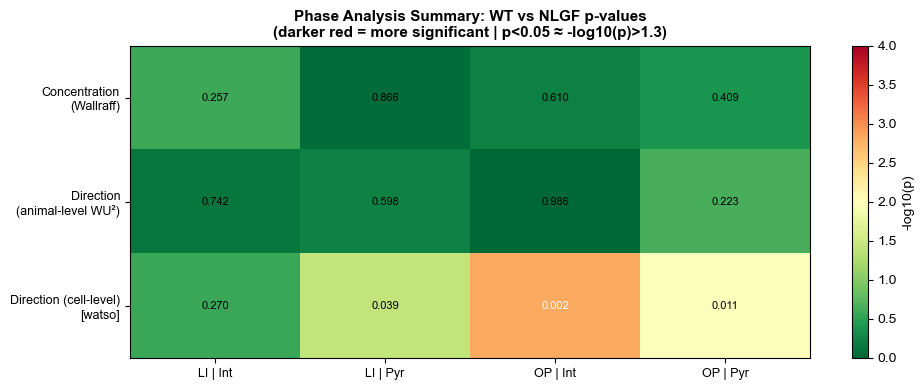

✅ Saved: 7_summary_heatmap.png


In [11]:
# Build a summary p-value matrix across all tests
summary_entries = []

# From direction tests (cell-level)
for _, row in df_direction.iterrows():
    label = f"{row['environment'][:2].upper()} | {row['cell_type'][:3]}"
    rec = row['recommended_test']
    primary_p = row['WW_p'] if rec == 'watson_williams' else row['WU2_p']
    summary_entries.append({
        'group': label,
        'test': f'Direction (cell-level)\n[{rec[:5]}]',
        'p': primary_p
    })

# From animal direction tests
for _, row in df_animal_direction.iterrows():
    label = f"{row['environment'][:2].upper()} | {row['cell_type'][:3]}"
    summary_entries.append({
        'group': label,
        'test': 'Direction\n(animal-level WU²)',
        'p': row.get('WU2_p', np.nan)
    })

# From Wallraff (concentration)
for _, row in df_wallraff.iterrows():
    label = f"{row['environment'][:2].upper()} | {row['cell_type'][:3]}"
    summary_entries.append({
        'group': label,
        'test': 'Concentration\n(Wallraff)',
        'p': row.get('wallraff_p', np.nan)
    })

df_summary = pd.DataFrame(summary_entries)

# Pivot for heatmap
try:
    pivot = df_summary.pivot_table(index='test', columns='group', values='p', aggfunc='first')

    fig, ax = plt.subplots(figsize=(max(8, len(pivot.columns) * 2.5), max(4, len(pivot.index) * 1.2)))

    log_p = -np.log10(pivot.values.astype(float).clip(1e-10, 1))
    im = ax.imshow(log_p, cmap='RdYlGn_r', vmin=0, vmax=4, aspect='auto')

    for i in range(log_p.shape[0]):
        for j in range(log_p.shape[1]):
            val = pivot.values[i, j]
            txt = f'{val:.3f}' if not np.isnan(val) else 'NA'
            color = 'white' if log_p[i, j] > 2 else 'black'
            ax.text(j, i, txt, ha='center', va='center', fontsize=8, color=color)

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, fontsize=9)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=9)

    plt.colorbar(im, ax=ax, label='-log10(p)')
    ax.set_title('Phase Analysis Summary: WT vs NLGF p-values\n'
                 '(darker red = more significant | p<0.05 ≈ -log10(p)>1.3)',
                 fontsize=11, fontweight='bold')

    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / '7_summary_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved: 7_summary_heatmap.png")

except Exception as e:
    print(f"Heatmap could not be generated: {e}")

## 11. Descriptive Summary Per Group

Full circular summary statistics (mean direction, concentration, angular deviation, Rayleigh test) for every environment × cell type × genotype combination.

In [12]:
descriptive_rows = []

for env in ENVIRONMENTS:
    for ct in CELL_TYPES:
        for geno in GENOTYPES:
            angles = get_angles(df, env, ct, geno)
            circ = make_circular(angles)
            if circ is None:
                continue

            # Animal-level stats
            animal_angles = animal_mean_angle(df, env, ct, geno)

            row = {
                'environment': env,
                'cell_type':   ct,
                'genotype':    geno,
                'n_cells':     circ.n,
                'n_animals':   len(animal_angles),
                'mean_direction_deg': round(np.degrees(circ.mean) % 360, 1),
                'mean_CI_lb_deg': round(np.degrees(circ.mean_lb) % 360, 1) if hasattr(circ, 'mean_lb') and not np.isnan(circ.mean_lb) else np.nan,
                'mean_CI_ub_deg': round(np.degrees(circ.mean_ub) % 360, 1) if hasattr(circ, 'mean_ub') and not np.isnan(circ.mean_ub) else np.nan,
                'median_direction_deg': round(np.degrees(circ.median) % 360, 1) if not np.isnan(circ.median) else np.nan,
                'concentration_r':     round(circ.r, 4),
                'kappa':               round(circ.kappa, 3),
                'angular_deviation_deg': round(np.degrees(circ.s), 2),
                'circular_skewness':   round(circ.skewness, 4),
                'circular_kurtosis':   round(circ.kurtosis, 4),
                'rayleigh_p':          round(circ.mean_test_result.pval, 6),
                'rayleigh_sig':        sig_label(circ.mean_test_result.pval),
                'animal_mean_deg':     round(np.degrees(circ_mean(animal_angles)) % 360, 1) if len(animal_angles) >= 2 else np.nan,
                'animal_r':            round(circ_r(animal_angles), 4) if len(animal_angles) >= 2 else np.nan,
            }
            descriptive_rows.append(row)

df_descriptive = pd.DataFrame(descriptive_rows)

display(HTML("<h3>Circular Descriptive Statistics — phase_mean</h3>"))
display(df_descriptive)

df_descriptive.to_csv(OUTPUT_DIR / '8_circular_descriptives.csv', index=False)
print("\n✅ Saved: 8_circular_descriptives.csv")

,environment,cell_type,genotype,n_cells,n_animals,mean_direction_deg,mean_CI_lb_deg,mean_CI_ub_deg,median_direction_deg,concentration_r,kappa,angular_deviation_deg,circular_skewness,circular_kurtosis,rayleigh_p,rayleigh_sig,animal_mean_deg,animal_r
0,open_field,Pyramidal,WT,409,8,186.2,176.0,196.4,193.9,0.3405,0.724,65.80,0.2645,0.3515,0.000000,***,190.5,0.6624
1,open_field,Pyramidal,NLGF,310,9,169.7,154.8,184.5,172.8,0.2987,0.626,67.86,0.0384,0.0782,0.000000,***,179.2,0.4472
2,open_field,Interneuron,WT,148,8,211.4,196.9,225.9,206.8,0.3651,0.784,64.56,-0.2037,0.8003,0.000000,***,185.8,0.5043
3,open_field,Interneuron,NLGF,211,9,194.6,183.7,205.5,191.8,0.3680,0.792,64.42,-0.6103,0.8337,0.000000,***,201.2,0.5136
4,linear_track,Pyramidal,WT,292,8,152.9,130.4,175.5,148.7,0.2058,0.421,72.21,0.0621,0.0393,0.000004,***,173.1,0.4556
5,linear_track,Pyramidal,NLGF,221,9,198.7,173.4,224.0,194.7,0.2071,0.423,72.15,0.0046,0.1539,0.000070,***,210.0,0.4090
6,linear_track,Interneuron,WT,101,8,213.2,192.1,234.3,207.9,0.3353,0.712,66.06,-0.2312,0.4189,0.000009,***,196.1,0.4116
7,linear_track,Interneuron,NLGF,146,9,233.0,211.9,254.2,230.9,0.2816,0.587,68.68,-0.2362,-0.3274,0.000008,***,206.7,0.3815



✅ Saved: 8_circular_descriptives.csv


## 12. Combined Output Summary

In [13]:
print("=" * 70)
print("PHASE CIRCULAR ANALYSIS — SUMMARY")
print("=" * 70)
print()
print("Files saved to:", OUTPUT_DIR)
print()
print("1_rayleigh_test_results.csv    — Phase preference per group")
print("2_direction_tests_WT_vs_NLGF.csv — Watson-Williams / Watson U² / Wheeler-Watson")
print("3_animal_level_direction_tests.csv — Same but using animal-level mean angles")
print("4_wallraff_concentration_test.csv — Differences in concentration (dispersion)")
print("5_circ_anova_results.csv       — Circular ANOVA (F-test and LRT)")
print("6_rose_diagrams_phase_mean.pdf — Visual summary")
print("7_summary_heatmap.png          — p-value overview")
print("8_circular_descriptives.csv    — Full descriptive statistics")
print()
print("=" * 70)
print("INTERPRETATION GUIDE")
print("=" * 70)
print()
print("Rayleigh test:")
print("  p < 0.05 → cells show significant directional preference")
print("  r > 0.7  → high concentration → use Watson-Williams")
print("  r ≤ 0.7  → low concentration  → use Watson U² or Wheeler-Watson")
print()
print("Watson-Williams F-test:")
print("  Tests whether WT and NLGF mean phase directions differ")
print("  Parametric — valid only when both groups have high concentration")
print()
print("Watson U² / Wheeler-Watson:")
print("  Non-parametric equivalents — use when concentration is low")
print("  or when distribution is non-unimodal")
print()
print("Wallraff test:")
print("  p < 0.05 → groups differ in HOW TIGHTLY they lock to theta")
print("  Complements direction tests — tells you about concentration, not angle")
print()
print("Animal-level tests:")
print("  More conservative (small n) but respects nested structure")
print("  Use to confirm cell-level results are not driven by a few mice")
print()
print("phase_locking_vector_length / phase_variance:")
print("  These are already scalar summary stats (not angles)")
print("  Analyse with the standard GLMM pipeline (beta family)")
print("  The Wallraff test indirectly captures the same question")
print("  for phase_mean data")

PHASE CIRCULAR ANALYSIS — SUMMARY

Files saved to: /Users/loukia/Library/CloudStorage/Dropbox-UCL/Loukia Katsouri/DataProtocolsEquipment/Ephys_Analysis/RobinData/Analysis/OF_concat/phase_circular_analysis

1_rayleigh_test_results.csv    — Phase preference per group
2_direction_tests_WT_vs_NLGF.csv — Watson-Williams / Watson U² / Wheeler-Watson
3_animal_level_direction_tests.csv — Same but using animal-level mean angles
4_wallraff_concentration_test.csv — Differences in concentration (dispersion)
5_circ_anova_results.csv       — Circular ANOVA (F-test and LRT)
6_rose_diagrams_phase_mean.pdf — Visual summary
7_summary_heatmap.png          — p-value overview
8_circular_descriptives.csv    — Full descriptive statistics

INTERPRETATION GUIDE

Rayleigh test:
  p < 0.05 → cells show significant directional preference
  r > 0.7  → high concentration → use Watson-Williams
  r ≤ 0.7  → low concentration  → use Watson U² or Wheeler-Watson

Watson-Williams F-test:
  Tests whether WT and NLGF mean 